<a href="https://colab.research.google.com/github/jairaj023/Internship-Practice/blob/main/Day_1Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy nltk spacy scikit-learn
!python -m spacy download en_core_web_sm

In [29]:
import re
import spacy
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [1]:
from google.colab import files
upload = files.upload()

Saving raw_jobs.csv to raw_jobs.csv


In [5]:
df = pd.read_csv('raw_jobs.csv')

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 9)


In [7]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['job_id', 'job_title', 'company', 'location', 'job_description', 'experience', 'education', 'salary', 'job_type']


In [8]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           10000 non-null  object
 1   job_title        10000 non-null  object
 2   company          10000 non-null  object
 3   location         10000 non-null  object
 4   job_description  10000 non-null  object
 5   experience       10000 non-null  object
 6   education        10000 non-null  object
 7   salary           10000 non-null  object
 8   job_type         10000 non-null  object
dtypes: object(9)
memory usage: 703.3+ KB


In [15]:
missing_values = df.isnull().sum()

print("Missing Values:\n", missing_values)

Missing Values:
 job_id             0
job_title          0
company            0
location           0
job_description    0
experience         0
education          0
salary             0
job_type           0
dtype: int64


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
for i in range(5):
    print(f"\nJob Description {i+1}:")
    print(df["job_description"].iloc[i])


Job Description 1:
We are looking for a Python Developer to join our team at Infosys. The candidate will work on data, software, and business projects. Required skills include Python, SQL, Flask. Candidates should have 1-3 years of experience and a MCA. Responsibilities include developing solutions, analyzing requirements, collaborating with teams, testing applications, documenting work, and delivering high-quality results.

Job Description 2:
We are looking for a Data Scientist to join our team at Infosys. The candidate will work on data, software, and business projects. Required skills include Python, SQL, Machine Learning, Pandas, Scikit-learn. Candidates should have 0-2 years of experience and a MCA. Responsibilities include developing solutions, analyzing requirements, collaborating with teams, testing applications, documenting work, and delivering high-quality results.

Job Description 3:
We are looking for a Data Engineer to join our team at IBM. The candidate will work on data

In [20]:
df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_"))

print(df.columns.tolist())

['job_id', 'job_title', 'company', 'location', 'job_description', 'experience', 'education', 'salary', 'job_type']


In [21]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9+#.\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [22]:
df["clean_description"] = df["job_description"].apply(clean_text)

df[["job_description", "clean_description"]].head()

,job_description,clean_description
0,We are looking for a Python Developer to join ...,we are looking for a python developer to join ...
1,We are looking for a Data Scientist to join ou...,we are looking for a data scientist to join ou...
2,We are looking for a Data Engineer to join our...,we are looking for a data engineer to join our...
3,We are looking for a Business Analyst to join ...,we are looking for a business analyst to join ...
4,We are looking for a Business Analyst to join ...,we are looking for a business analyst to join ...


In [23]:
skills_list = [
    "python",
    "java",
    "c++",
    "javascript",
    "typescript",
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "pytorch",
    "keras",
    "matplotlib",
     "seaborn",
    "spacy",
    "nltk",
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "data analysis",
    "data analytics",
    "data science",
    "power bi",
    "tableau",
    "excel",
    "aws",
    "azure",
    "google cloud",
    "docker",
    "kubernetes",
    "git",
    "github",
    "flask",
    "fastapi",
    "django",
    "react",
    "node.js",
    "html",
    "css",
    "bootstrap",
    "tailwind css"
]

In [24]:
def extract_skills(text):
    text = clean_text(text)

    found_skills = []

    for skill in skills_list:
        pattern = r"\b" + re.escape(skill) + r"\b"

        if re.search(pattern, text):
            found_skills.append(skill)

    return found_skills

In [25]:
sample_text = """We require a Data Scientist with Python, Pandas, NumPy, Scikit-learn, SQL and AWS experience."""

print(extract_skills(sample_text))

['python', 'sql', 'pandas', 'numpy', 'aws']


In [26]:
df["predicted_skills"] = df["job_description"].apply(extract_skills)

df[["job_title", "predicted_skills"]].head(10)

,job_title,predicted_skills
0,Python Developer,"[python, sql, flask]"
1,Data Scientist,"[python, sql, pandas, machine learning]"
2,Data Engineer,"[python, sql]"
3,Business Analyst,"[sql, data analysis, power bi]"
4,Business Analyst,"[sql, data analysis, power bi]"
5,Software Engineer,"[python, java, git]"
6,Frontend Developer,"[javascript, react, html, css, tailwind css]"
7,AI Engineer,"[machine learning, deep learning]"
8,Frontend Developer,"[react, html, css, tailwind css]"
9,AI Engineer,"[python, machine learning, deep learning]"


In [27]:
all_skills = []

for skills in df["predicted_skills"]:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

skill_counts.most_common(20)

[('sql', 4853),
 ('python', 4170),
 ('excel', 1606),
 ('java', 1352),
 ('power bi', 1320),
 ('machine learning', 1317),
 ('css', 1285),
 ('git', 1228),
 ('html', 1205),
 ('react', 1193),
 ('javascript', 1160),
 ('aws', 1156),
 ('tensorflow', 821),
 ('node.js', 806),
 ('docker', 777),
 ('mysql', 765),
 ('deep learning', 426),
 ('data analysis', 418),
 ('django', 413),
 ('tailwind css', 401)]

In [28]:
skill_df = pd.DataFrame(skill_counts.items(), columns=["Skill", "Frequency"])

skill_df = skill_df.sort_values(by="Frequency", ascending=False)

skill_df.head(20)

,Skill,Frequency
1,sql,4853
0,python,4170
16,excel,1606
7,java,1352
6,power bi,1320
4,machine learning,1317
12,css,1285
8,git,1228
11,html,1205
10,react,1193


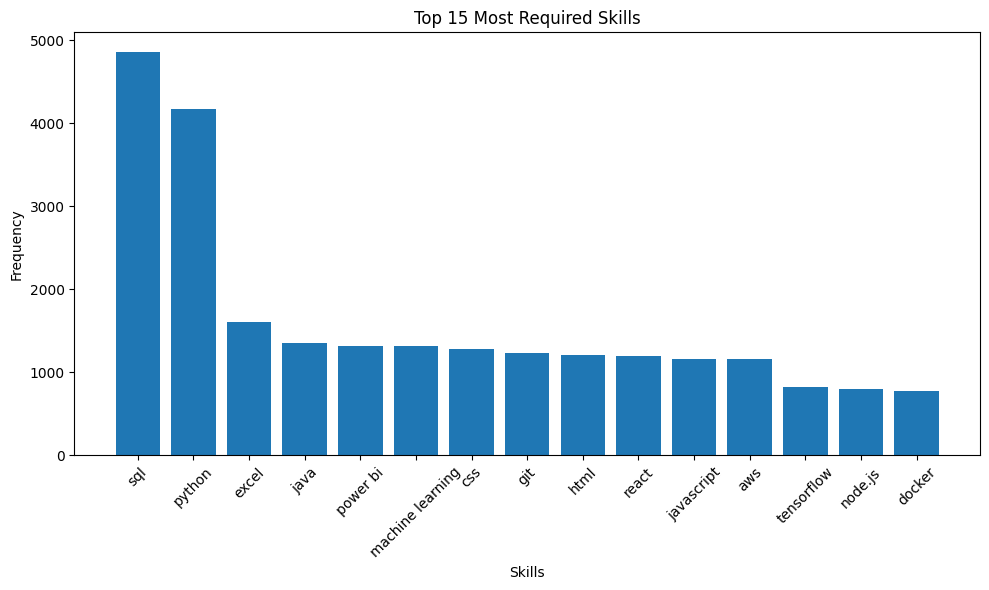

In [30]:
top_skills = skill_df.head(15)

plt.figure(figsize=(10, 6))

plt.bar(top_skills["Skill"], top_skills["Frequency"])

plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.title("Top 15 Most Required Skills")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
def create_output(row):
    return {"role": row["job_title"], "skills": row["predicted_skills"]}

In [32]:
result = create_output(df.iloc[0])

print(result)

{'role': 'Python Developer', 'skills': ['python', 'sql', 'flask']}


In [34]:
output_df = df[["job_id", "job_title", "job_description", "predicted_skills"]]

output_df.to_csv("skill_extraction_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [35]:
def convert_existing_skills(value):
    if pd.isna(value):
        return []

    value = str(value).lower()

    skills = []

    for skill in skills_list:
        if re.search(r"\b" + re.escape(skill) + r"\b", value):
            skills.append(skill)

    return skills